In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
sns.set()

In [2]:
import datetime as dt

In [3]:
ticker = "EURUSD=X"
years = 3
end = dt.date.today()
start = end - dt.timedelta(years*365)

In [4]:
raw_data = yf.download(ticker,start = start, end = end, auto_adjust=True)

[*********************100%***********************]  1 of 1 completed


In [5]:
raw_data.head()

Price,Close,High,Low,Open,Volume
Ticker,EURUSD=X,EURUSD=X,EURUSD=X,EURUSD=X,EURUSD=X
Date,,,,,
2022-04-26,1.071421,1.073883,1.064464,1.071421,0
2022-04-27,1.064362,1.065644,1.051669,1.064362,0
2022-04-28,1.055509,1.056223,1.047285,1.055509,0
2022-04-29,1.050420,1.059042,1.050542,1.050420,0
2022-05-02,1.053596,1.056770,1.050398,1.053596,0


In [6]:
raw_data.columns = raw_data.columns.get_level_values(0)
raw_data.columns.name = None

In [7]:
raw_data.head()

,Close,High,Low,Open,Volume
Date,,,,,
2022-04-26,1.071421,1.073883,1.064464,1.071421,0
2022-04-27,1.064362,1.065644,1.051669,1.064362,0
2022-04-28,1.055509,1.056223,1.047285,1.055509,0
2022-04-29,1.050420,1.059042,1.050542,1.050420,0
2022-05-02,1.053596,1.056770,1.050398,1.053596,0


In [8]:
data = raw_data[["Close"]]

In [9]:
control = data.copy()

In [10]:
data.head()

,Close
Date,
2022-04-26,1.071421
2022-04-27,1.064362
2022-04-28,1.055509
2022-04-29,1.050420
2022-05-02,1.053596


<Axes: xlabel='Date'>

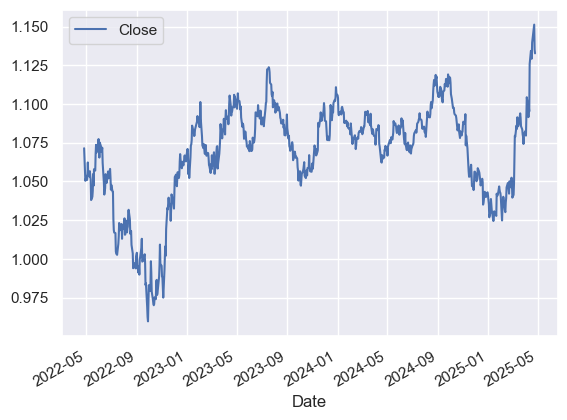

In [11]:
data.plot()

In [12]:
data["Returns"] = np.log(data/data.shift(1))

C:\Users\Bello\AppData\Local\Temp\ipykernel_3240\2432235809.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data["Returns"] = np.log(data/data.shift(1))


In [13]:
data

,Close,Returns
Date,,
2022-04-26,1.071421,NaN
2022-04-27,1.064362,-0.006610
2022-04-28,1.055509,-0.008352
2022-04-29,1.050420,-0.004833
2022-05-02,1.053596,0.003019
...,...,...
2025-04-16,1.129267,-0.004153
2025-04-17,1.139679,0.009178
2025-04-22,1.151278,0.010126


In [47]:
sma_s = 31
sma_l = 101

In [48]:
data["sma_s"] = data["Close"].rolling(sma_s).mean()
data["sma_l"] = data["Close"].rolling(sma_l).mean()

In [49]:
data.head()

,Close,Returns,sma_s,sma_l,Position,strategy,cumret,cumstrat
Date,,,,,,,,
2023-01-30,1.087146,-0.002111,NaN,NaN,1,0.002111,0.997891,1.002113
2023-01-31,1.085069,-0.001912,NaN,NaN,1,-0.001912,0.995985,1.000200
2023-02-01,1.086095,0.000944,NaN,NaN,1,0.000944,0.996926,1.001145
2023-02-02,1.101285,0.013889,NaN,NaN,1,0.013889,1.010870,1.015147
2023-02-03,1.090513,-0.009830,NaN,NaN,1,-0.009830,1.000982,1.005217


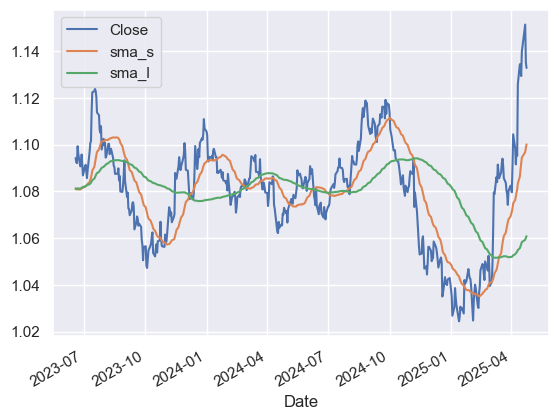

In [50]:
data[["Close","sma_s","sma_l"]].dropna().plot()
plt.show()

In [51]:
data["Returns"].cumsum().apply(np.exp)

Date
2023-01-30    0.997891
2023-01-31    0.995985
2023-02-01    0.996926
2023-02-02    1.010870
2023-02-03    1.000982
                ...   
2025-04-16    1.036554
2025-04-17    1.046112
2025-04-22    1.056758
2025-04-23    1.041932
2025-04-24    1.039736
Name: Returns, Length: 581, dtype: float64

In [52]:
(data["Close"].iloc[-1]-data["Close"].iloc[0])/data.Close.iloc[0]

np.float64(0.04193379167023954)

In [53]:
data["Position"] = np.where(data.sma_s > data.sma_l, 1,-1)

<Axes: xlabel='Date'>

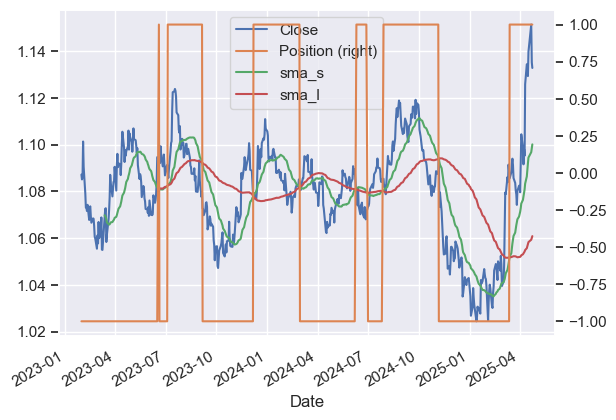

In [54]:
data[["Close","Position","sma_s","sma_l"]].plot(secondary_y = "Position")

In [55]:
data.head()

,Close,Returns,sma_s,sma_l,Position,strategy,cumret,cumstrat
Date,,,,,,,,
2023-01-30,1.087146,-0.002111,NaN,NaN,-1,0.002111,0.997891,1.002113
2023-01-31,1.085069,-0.001912,NaN,NaN,-1,-0.001912,0.995985,1.000200
2023-02-01,1.086095,0.000944,NaN,NaN,-1,0.000944,0.996926,1.001145
2023-02-02,1.101285,0.013889,NaN,NaN,-1,0.013889,1.010870,1.015147
2023-02-03,1.090513,-0.009830,NaN,NaN,-1,-0.009830,1.000982,1.005217


In [56]:
data["strategy"] = data.Position.shift(1)*data.Returns

In [57]:
data.head()

,Close,Returns,sma_s,sma_l,Position,strategy,cumret,cumstrat
Date,,,,,,,,
2023-01-30,1.087146,-0.002111,NaN,NaN,-1,NaN,0.997891,1.002113
2023-01-31,1.085069,-0.001912,NaN,NaN,-1,0.001912,0.995985,1.000200
2023-02-01,1.086095,0.000944,NaN,NaN,-1,-0.000944,0.996926,1.001145
2023-02-02,1.101285,0.013889,NaN,NaN,-1,-0.013889,1.010870,1.015147
2023-02-03,1.090513,-0.009830,NaN,NaN,-1,0.009830,1.000982,1.005217


In [58]:
data.dropna(inplace=True)

In [59]:
data["cumret"] = data.Returns.cumsum().apply(np.exp)
data["cumstrat"] = data.strategy.cumsum().apply(np.exp)

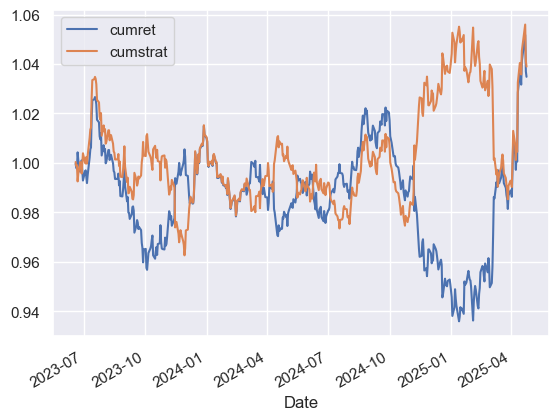

In [60]:
data[["cumret","cumstrat"]].plot()
plt.show()

In [28]:
np.exp(data["strategy"].sum())

np.float64(0.7782376179193234)

In [35]:
data["cumstrat"].iloc[-1]

np.float64(0.7782376179193234)

In [29]:
np.exp(data["Returns"].sum())

np.float64(1.0397363493597493)

In [32]:
def test_strategy(SMA):
    df = control.copy()
    df["Returns"] = np.log(df.Close/df.Close.shift(1))
    df["Sma_S"] = df.Close.rolling(int(SMA[0])).mean()
    df["Sma_L"] = df.Close.rolling(int(SMA[1])).mean()
    df.dropna(inplace=True)
    df["Position"] = np.where(df.Sma_S > df.Sma_L,1,-1)
    df["Strategy"] = df.Position.shift(1)*df.Returns
    df.dropna(inplace=True)

    return np.exp(df.Strategy.sum())

In [33]:
test_strategy((50,200))

np.float64(0.7765963118373985)

In [36]:
from itertools import product

In [37]:
sma_s_range = range(10,50,1)
sma_l_range = range(100,252,1)

In [38]:
combinations = list(product(sma_s_range,sma_l_range))

In [39]:
results = []
for comb in combinations:
    results.append(test_strategy(comb))

In [40]:
np.max(results)

np.float64(1.0626702253361102)

In [41]:
np.argmax(results)

np.int64(3193)

In [42]:
many_results = pd.DataFrame(data = combinations, columns = ["SMA_S", "SMA_L"])

In [43]:
many_results["performance"] = results

In [44]:
many_results.head()

,SMA_S,SMA_L,performance
0,10,100,0.975076
1,10,101,0.971262
2,10,102,0.959321
3,10,103,0.966224
4,10,104,0.965937


In [45]:
many_results.nlargest(10,"performance")

,SMA_S,SMA_L,performance
3193,31,101,1.062670
3192,31,100,1.060848
3043,30,103,1.058938
3046,30,106,1.056180
3045,30,105,1.055714
3044,30,104,1.052129
3041,30,101,1.046719
3349,32,105,1.046386
3801,35,101,1.046103
2638,27,154,1.041176


In [46]:
many_results.nsmallest(10,"performance")

,SMA_S,SMA_L,performance
5417,45,197,0.732889
5416,45,196,0.733823
5570,46,198,0.736610
5879,48,203,0.739337
5569,46,197,0.739766
5263,44,195,0.742787
5870,48,194,0.746250
5568,46,196,0.747557
5878,48,202,0.749477
6031,49,203,0.750004


In [61]:
data.head()

,Close,Returns,sma_s,sma_l,Position,strategy,cumret,cumstrat
Date,,,,,,,,
2023-06-19,1.094212,-0.000350,1.081353,1.080997,1,0.000350,0.999650,1.000350
2023-06-20,1.092430,-0.001629,1.081049,1.081050,-1,-0.001629,0.998023,0.998722
2023-06-21,1.092037,-0.000360,1.080805,1.081119,-1,0.000360,0.997663,0.999082
2023-06-22,1.099264,0.006596,1.080895,1.081249,-1,-0.006596,1.004265,0.992514
2023-06-23,1.095890,-0.003073,1.080814,1.081196,-1,0.003073,1.001184,0.995569


In [62]:
trades = data.Position.diff().abs()

In [64]:
trades.value_counts()

Position
0.0    470
2.0     10
Name: count, dtype: int64

In [65]:
ptc = 0.001

In [66]:
data["trades"] = data.Position.diff().abs()

In [67]:
data["strategy_net"] = data.strategy - data.trades*ptc

In [68]:
data["cstrategy_net"] = data.strategy_net.cumsum().apply(np.exp)

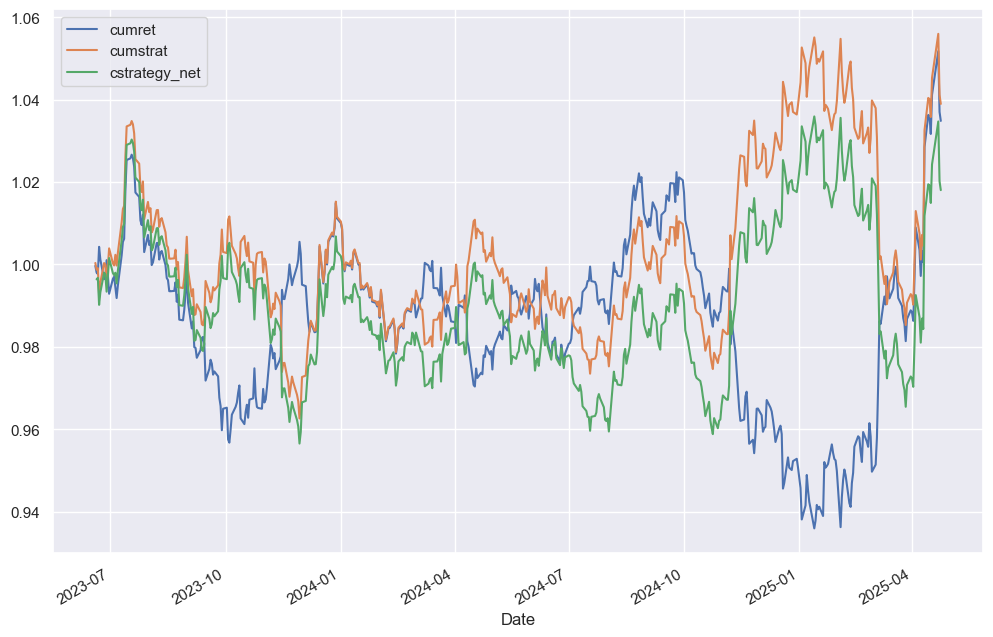

In [69]:
data[["cumret", "cumstrat", "cstrategy_net"]].plot(figsize = (12 , 8))
plt.show()